   epoch  train_mse  train_rel_l2   val_mse   val_mae  val_rel_l2     lr
0      1   0.661834      0.865725  0.430743  0.265511    1.077976  0.001
1      2   0.443191      0.747739  0.360346  0.164792    0.653684  0.001
2      3   0.390636      0.662030  0.315422  0.153134    0.608425  0.001
3      4   0.338582      0.604626  0.267778  0.137117    0.558074  0.001
4      5   0.309737      0.579296  0.232790  0.130374    0.540334  0.001

Columns:
['epoch', 'train_mse', 'train_rel_l2', 'val_mse', 'val_mae', 'val_rel_l2', 'lr']
Best Val MSE    = 0.086950 at epoch 522
Best Val Rel L2 = 0.259117 at epoch 522
Best Val MAE    = 0.054398 at epoch 835
Best Val MSE = 0.086950 at epoch 522
Best Val Rel L2 = 0.259117 at epoch 522
Best Val MAE = 0.054398 at epoch 835


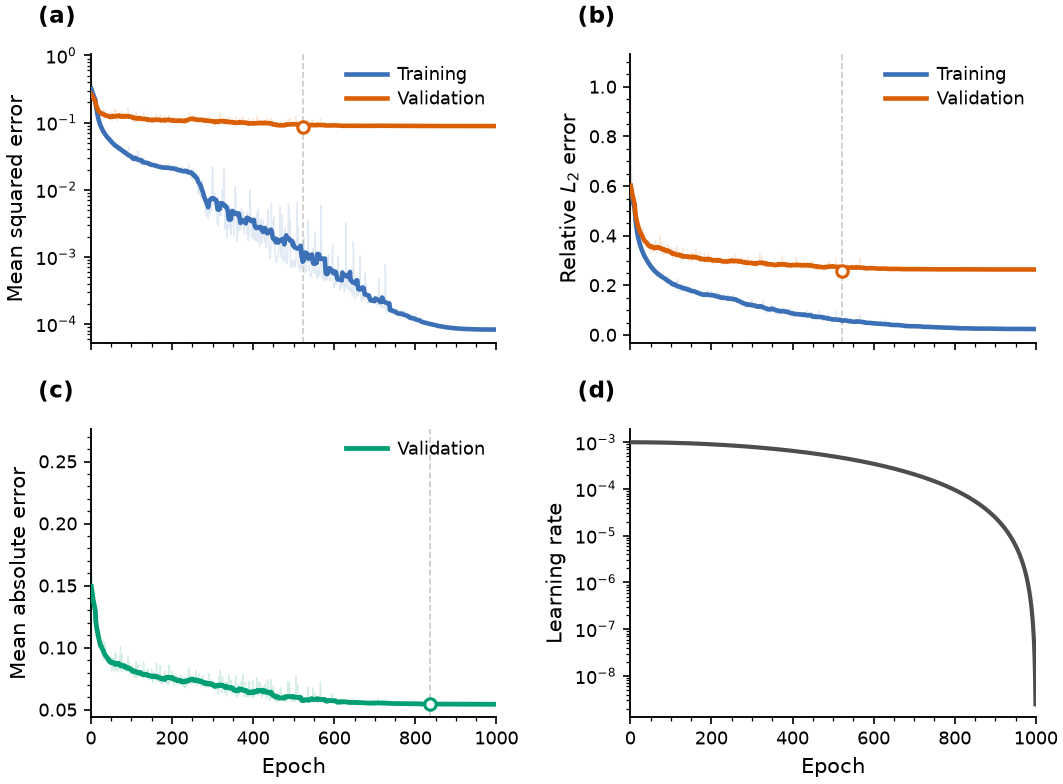

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path


# ============================================================
# 1. Load data
# ============================================================
csv_path = "training_log.csv"

df = pd.read_csv(csv_path)

print(df.head())
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 2. Smooth curves
# ============================================================
smooth_window = 20

metrics = [
    "train_mse",
    "val_mse",
    "train_rel_l2",
    "val_rel_l2",
    "val_mae",
]

for col in metrics:
    df[f"{col}_smooth"] = (
        df[col]
        .rolling(
            window=smooth_window,
            center=True,
            min_periods=1
        )
        .mean()
    )


# ============================================================
# 3. Nature-style color palette
# ============================================================
# Restrained, publication-friendly colors
COLOR_TRAIN = "#3B6FB6"    # deep muted blue
COLOR_VAL   = "#D95F02"    # orange-red
COLOR_MAE   = "#009E73"    # teal green
COLOR_LR    = "#4D4D4D"    # charcoal gray


# ============================================================
# 4. Global plotting style
# ============================================================
mpl.rcParams.update({

    # --------------------------------------------------------
    # Font
    # --------------------------------------------------------
    "font.family": "sans-serif",

    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans"
    ],

    "font.size": 9,

    "axes.labelsize": 10,
    "axes.titlesize": 10,

    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,

    "legend.fontsize": 8.5,

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------
    "axes.linewidth": 0.9,

    # --------------------------------------------------------
    # Ticks
    # --------------------------------------------------------
    "xtick.direction": "out",
    "ytick.direction": "out",

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "figure.dpi": 150,
    "savefig.dpi": 600,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
})


# ============================================================
# 5. Find best validation checkpoint
# ============================================================
best_mse_idx = df["val_mse"].idxmin()
best_rel_idx = df["val_rel_l2"].idxmin()
best_mae_idx = df["val_mae"].idxmin()

best_mse_epoch = int(df.loc[best_mse_idx, "epoch"])
best_rel_epoch = int(df.loc[best_rel_idx, "epoch"])
best_mae_epoch = int(df.loc[best_mae_idx, "epoch"])


print(
    f"Best Val MSE    = "
    f"{df.loc[best_mse_idx, 'val_mse']:.6f} "
    f"at epoch {best_mse_epoch}"
)

print(
    f"Best Val Rel L2 = "
    f"{df.loc[best_rel_idx, 'val_rel_l2']:.6f} "
    f"at epoch {best_rel_epoch}"
)

print(
    f"Best Val MAE    = "
    f"{df.loc[best_mae_idx, 'val_mae']:.6f} "
    f"at epoch {best_mae_epoch}"
)


# ============================================================
# 6. Create figure
# ============================================================
fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.2, 5.2)
)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]


# ============================================================
# Panel label helper
# ============================================================
def panel_label(ax, label):

    ax.text(
        -0.13,
        1.17,
        label,
        transform=ax.transAxes,

        fontsize=11,
        fontweight="bold",

        va="top",
        ha="left"
    )


# ============================================================
# (a) Mean squared error
# ============================================================

# ---------- raw curves ----------
ax1.plot(
    df["epoch"],
    df["train_mse"],
    color=COLOR_TRAIN,
    linewidth=0.65,
    alpha=0.15,
    zorder=1
)

ax1.plot(
    df["epoch"],
    df["val_mse"],
    color=COLOR_VAL,
    linewidth=0.65,
    alpha=0.15,
    zorder=1
)


# ---------- smoothed curves ----------
ax1.plot(
    df["epoch"],
    df["train_mse_smooth"],
    color=COLOR_TRAIN,
    linewidth=2.2,
    label="Training",
    zorder=3
)

ax1.plot(
    df["epoch"],
    df["val_mse_smooth"],
    color=COLOR_VAL,
    linewidth=2.2,
    label="Validation",
    zorder=3
)


# ---------- best point ----------
ax1.scatter(
    best_mse_epoch,
    df.loc[best_mse_idx, "val_mse"],

    s=30,

    facecolor="white",
    edgecolor=COLOR_VAL,

    linewidth=1.5,
    zorder=5
)


ax1.set_yscale("log")

ax1.set_ylabel("Mean squared error")

panel_label(ax1, "(a)")

ax1.legend(
    frameon=False,
    loc="upper right",

    handlelength=2.3,
    handletextpad=0.6,

    borderpad=0.15,
    labelspacing=0.35
)


# ============================================================
# (b) Relative L2 error
# ============================================================

# ---------- raw ----------
ax2.plot(
    df["epoch"],
    df["train_rel_l2"],
    color=COLOR_TRAIN,

    linewidth=0.65,
    alpha=0.15,

    zorder=1
)

ax2.plot(
    df["epoch"],
    df["val_rel_l2"],
    color=COLOR_VAL,

    linewidth=0.65,
    alpha=0.15,

    zorder=1
)


# ---------- smooth ----------
ax2.plot(
    df["epoch"],
    df["train_rel_l2_smooth"],

    color=COLOR_TRAIN,

    linewidth=2.2,

    label="Training",
    zorder=3
)

ax2.plot(
    df["epoch"],
    df["val_rel_l2_smooth"],

    color=COLOR_VAL,

    linewidth=2.2,

    label="Validation",
    zorder=3
)


# ---------- best point ----------
ax2.scatter(
    best_rel_epoch,
    df.loc[best_rel_idx, "val_rel_l2"],

    s=30,

    facecolor="white",
    edgecolor=COLOR_VAL,

    linewidth=1.5,
    zorder=5
)


ax2.set_ylabel(r"Relative $L_2$ error")

panel_label(ax2, "(b)")

ax2.legend(
    frameon=False,
    loc="upper right",

    handlelength=2.3,
    handletextpad=0.6,

    borderpad=0.15,
    labelspacing=0.35
)


# ============================================================
# (c) Validation MAE
# ============================================================

# ---------- raw ----------
ax3.plot(
    df["epoch"],
    df["val_mae"],

    color=COLOR_MAE,

    linewidth=0.65,
    alpha=0.17,

    zorder=1
)


# ---------- smooth ----------
ax3.plot(
    df["epoch"],
    df["val_mae_smooth"],

    color=COLOR_MAE,

    linewidth=2.3,

    label="Validation",
    zorder=3
)


# ---------- best point ----------
ax3.scatter(
    best_mae_epoch,
    df.loc[best_mae_idx, "val_mae"],

    s=30,

    facecolor="white",
    edgecolor=COLOR_MAE,

    linewidth=1.5,

    zorder=5
)


ax3.set_xlabel("Epoch")
ax3.set_ylabel("Mean absolute error")

panel_label(ax3, "(c)")

ax3.legend(
    frameon=False,
    loc="upper right",

    handlelength=2.3,
    handletextpad=0.6,

    borderpad=0.15
)


# ============================================================
# (d) Learning-rate schedule
# ============================================================

# log scale cannot show zero
lr_plot = df["lr"].replace(0, np.nan)

ax4.plot(
    df["epoch"],
    lr_plot,

    color=COLOR_LR,

    linewidth=2.0,

    zorder=3
)

ax4.set_yscale("log")

ax4.set_xlabel("Epoch")
ax4.set_ylabel("Learning rate")

panel_label(ax4, "(d)")


# ============================================================
# 7. Common Nature-style formatting
# ============================================================
for ax in axes.flat:

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    # Tick settings
    ax.tick_params(
        axis="both",
        which="both",

        direction="out",

        top=False,
        right=False,

        pad=3
    )

    ax.minorticks_on()

    # Epoch range
    ax.set_xlim(
        df["epoch"].min(),
        df["epoch"].max()
    )

    ax.set_xticks([
        0,
        200,
        400,
        600,
        800,
        1000
    ])

    # No grid
    ax.grid(False)

    ax.margins(x=0)


# Hide top-row x labels
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)


# ============================================================
# Find best epoch for each metric separately
# ============================================================

best_mse_idx = df["val_mse"].idxmin()
best_rel_idx = df["val_rel_l2"].idxmin()
best_mae_idx = df["val_mae"].idxmin()

best_mse_epoch = int(df.loc[best_mse_idx, "epoch"])
best_rel_epoch = int(df.loc[best_rel_idx, "epoch"])
best_mae_epoch = int(df.loc[best_mae_idx, "epoch"])

print(
    f"Best Val MSE = {df.loc[best_mse_idx, 'val_mse']:.6f} "
    f"at epoch {best_mse_epoch}"
)

print(
    f"Best Val Rel L2 = {df.loc[best_rel_idx, 'val_rel_l2']:.6f} "
    f"at epoch {best_rel_epoch}"
)

print(
    f"Best Val MAE = {df.loc[best_mae_idx, 'val_mae']:.6f} "
    f"at epoch {best_mae_epoch}"
)

# MSE best epoch
ax1.axvline(
    best_mse_epoch,
    color="#888888",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45,
    zorder=0
)

# Relative L2 best epoch
ax2.axvline(
    best_rel_epoch,
    color="#888888",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45,
    zorder=0
)

# MAE best epoch
ax3.axvline(
    best_mae_epoch,
    color="#888888",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45,
    zorder=0
)

# ============================================================
# 9. Figure spacing
# ============================================================
plt.subplots_adjust(
    left=0.11,
    right=0.985,

    bottom=0.11,
    top=0.96,

    wspace=0.33,
    hspace=0.30
)


# ============================================================
# 10. Save publication-quality figure
# ============================================================
output_dir = Path("loss_figures")
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    output_dir / "training_loss_model2_nature.pdf"
)

fig.savefig(
    output_dir / "training_loss_model2_nature.svg"
)

fig.savefig(
    output_dir / "training_loss_model2_nature.png",
    dpi=600
)

plt.show()